# Catálogo de testes clássicos

**Tema:** Estatística › Testes de Hipótese

Escolher o teste é uma decisão de três perguntas:

1. **O que estou comparando?** (médias, proporções, distribuições, associação)
2. **Quantos grupos?** (um, dois, três ou mais)
3. **Os grupos são independentes ou pareados?**

E depois: os **pressupostos** do teste escolhido são plausíveis? Este notebook
testa esses pressupostos empiricamente, em vez de assumi-los.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(4321)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. A árvore de decisão

In [2]:
arvore = pd.DataFrame([
    ("Média vs. valor fixo", "1 amostra", "—", "t de uma amostra",
     "Wilcoxon (sinais)"),
    ("Duas médias", "2 grupos", "independentes", "t de WELCH",
     "Mann-Whitney U"),
    ("Duas médias", "2 grupos", "pareados", "t pareado",
     "Wilcoxon pareado"),
    ("3+ médias", "k grupos", "independentes", "ANOVA (ou Welch-ANOVA)",
     "Kruskal-Wallis"),
    ("3+ médias", "k grupos", "medidas repetidas", "ANOVA de medidas repetidas",
     "Friedman"),
    ("Duas proporções", "2 grupos", "independentes", "z de proporções / qui²",
     "Exato de Fisher (n pequeno)"),
    ("Duas proporções", "2 grupos", "pareados", "McNemar", "—"),
    ("Associação entre categóricas", "tabela r×c", "—", "Qui² de independência",
     "Exato de Fisher"),
    ("Duas distribuições inteiras", "2 amostras", "—", "Kolmogorov-Smirnov",
     "Anderson-Darling / permutação"),
    ("Correlação", "2 variáveis", "—", "Pearson", "Spearman / Kendall"),
], columns=["O que comparar", "Grupos", "Estrutura", "Teste paramétrico",
            "Alternativa não-paramétrica"])
arvore

,O que comparar,Grupos,Estrutura,Teste paramétrico,Alternativa não-paramétrica
0,Média vs. valor fixo,1 amostra,—,t de uma amostra,Wilcoxon (sinais)
1,Duas médias,2 grupos,independentes,t de WELCH,Mann-Whitney U
2,Duas médias,2 grupos,pareados,t pareado,Wilcoxon pareado
3,3+ médias,k grupos,independentes,ANOVA (ou Welch-ANOVA),Kruskal-Wallis
4,3+ médias,k grupos,medidas repetidas,ANOVA de medidas repetidas,Friedman
5,Duas proporções,2 grupos,independentes,z de proporções / qui²,Exato de Fisher (n pequeno)
6,Duas proporções,2 grupos,pareados,McNemar,—
7,Associação entre categóricas,tabela r×c,—,Qui² de independência,Exato de Fisher
8,Duas distribuições inteiras,2 amostras,—,Kolmogorov-Smirnov,Anderson-Darling / permutação
9,Correlação,2 variáveis,—,Pearson,Spearman / Kendall


> **A recomendação mais importante da tabela:** para duas médias
> independentes, use **Welch** (`equal_var=False`), não o t de Student
> clássico. O Welch não exige variâncias iguais e perde quase nada de poder
> quando elas são iguais. Vamos provar isso.

## 2. Student vs. Welch: por que Welch deve ser o padrão

Vamos medir a taxa real de erro tipo I dos dois testes quando as variâncias
**diferem** — situação corriqueira (grupos com tamanhos e comportamentos
distintos).

In [3]:
def taxa_erro_tipo1(n1, n2, sd1, sd2, n_sim=20_000):
    """Simula H0 verdadeira (mesmas médias) e conta rejeições."""
    a = rng.normal(0, sd1, (n_sim, n1))
    b = rng.normal(0, sd2, (n_sim, n2))
    p_student = stats.ttest_ind(a, b, axis=1, equal_var=True).pvalue
    p_welch = stats.ttest_ind(a, b, axis=1, equal_var=False).pvalue
    return (p_student < 0.05).mean(), (p_welch < 0.05).mean()


cenarios = [
    ("Grupos iguais (n=30/30, sd=1/1)", 30, 30, 1.0, 1.0),
    ("Variâncias diferentes, n igual", 30, 30, 1.0, 3.0),
    ("n desigual, grupo MENOR com variância MAIOR", 10, 50, 3.0, 1.0),
    ("n desigual, grupo MAIOR com variância MAIOR", 10, 50, 1.0, 3.0),
]
print(f"{'cenário':46s} {'Student':>9s} {'Welch':>8s}   (nominal: 5,0%)")
print("-" * 78)
for nome, n1, n2, s1, s2 in cenarios:
    ts, tw = taxa_erro_tipo1(n1, n2, s1, s2)
    print(f"{nome:46s} {ts:>8.1%} {tw:>8.1%}")

cenário                                          Student    Welch   (nominal: 5,0%)
------------------------------------------------------------------------------
Grupos iguais (n=30/30, sd=1/1)                    4.9%     4.9%
Variâncias diferentes, n igual                     5.5%     5.3%
n desigual, grupo MENOR com variância MAIOR       28.6%     4.8%


n desigual, grupo MAIOR com variância MAIOR        0.0%     4.8%


Leia as duas últimas linhas. Quando o grupo **menor** tem variância **maior**,
o teste de Student rejeita muito acima de 5% — ele mente sobre a própria taxa
de erro. Quando o grupo maior tem variância maior, ele fica conservador demais
(perde poder). O Welch fica em ~5% nos quatro cenários.

> **E o "teste de Levene primeiro, depois escolhe"?** Essa prática é
> *pior* que usar Welch direto. O pré-teste é ele próprio um teste, com sua
> própria taxa de erro, e a decisão condicional distorce a taxa do teste
> principal. A literatura moderna é unânime: **use Welch sempre**.

## 3. Quando o não-paramétrico ganha (e quando perde)

Testes não-paramétricos usam **postos** em vez de valores. Isso os torna
robustos a outliers e livres de suposição de normalidade — ao custo de algum
poder quando os dados **são** normais.

situação                                       t-Welch   Mann-Whitney
----------------------------------------------------------------------


Normal, sem efeito (mede erro tipo I)             5.2%           5.1%


Normal, com efeito                               67.4%          64.8%


Log-normal, com efeito (assimétrica)             48.7%          65.4%


Normal + 8% de outliers, com efeito              15.1%          53.6%


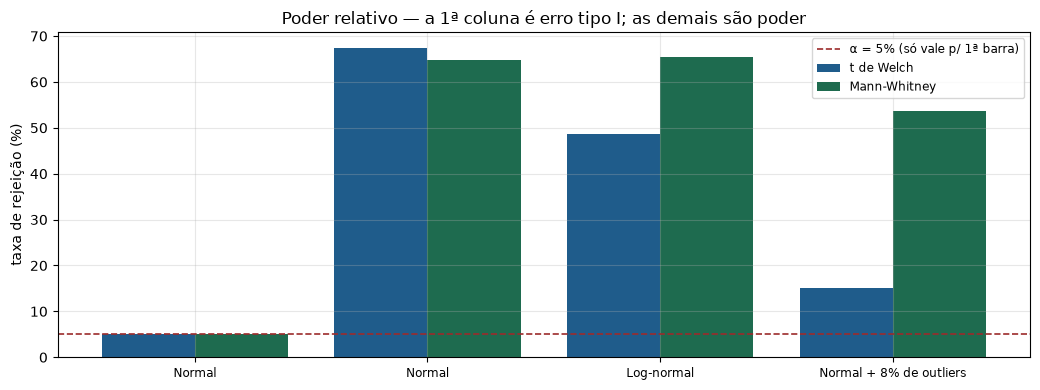

In [4]:
def compara_poder(gerador_a, gerador_b, n=40, n_sim=8_000):
    """Poder (ou erro tipo I, se não houver efeito) de t-Welch vs Mann-Whitney."""
    a = gerador_a((n_sim, n))
    b = gerador_b((n_sim, n))
    p_t = stats.ttest_ind(a, b, axis=1, equal_var=False).pvalue
    p_mw = np.array([stats.mannwhitneyu(a[i], b[i]).pvalue for i in range(n_sim)])
    return (p_t < 0.05).mean(), (p_mw < 0.05).mean()


DESLOC = 0.55
situacoes = {
    "Normal, sem efeito (mede erro tipo I)":
        (lambda t: rng.normal(0, 1, t), lambda t: rng.normal(0, 1, t)),
    "Normal, com efeito":
        (lambda t: rng.normal(0, 1, t), lambda t: rng.normal(DESLOC, 1, t)),
    "Log-normal, com efeito (assimétrica)":
        (lambda t: rng.lognormal(0, 1, t), lambda t: rng.lognormal(DESLOC, 1, t)),
    "Normal + 8% de outliers, com efeito":
        (lambda t: rng.normal(0, 1, t) + (rng.random(t) < 0.08) * rng.normal(0, 12, t),
         lambda t: rng.normal(DESLOC, 1, t) + (rng.random(t) < 0.08) * rng.normal(0, 12, t)),
}

print(f"{'situação':44s} {'t-Welch':>9s} {'Mann-Whitney':>14s}")
print("-" * 70)
resultados = []
for nome, (ga, gb) in situacoes.items():
    pt, pm = compara_poder(ga, gb)
    resultados.append({"situação": nome, "t-Welch": pt, "Mann-Whitney": pm})
    print(f"{nome:44s} {pt:>9.1%} {pm:>14.1%}")

fig, ax = plt.subplots(figsize=(10.5, 4))
res = pd.DataFrame(resultados)
x = np.arange(len(res))
ax.bar(x - 0.2, res["t-Welch"] * 100, 0.4, label="t de Welch", color=AZUL)
ax.bar(x + 0.2, res["Mann-Whitney"] * 100, 0.4, label="Mann-Whitney", color=VERDE)
ax.axhline(5, ls="--", color=VERMELHO, lw=1.2, label="α = 5% (só vale p/ 1ª barra)")
ax.set_xticks(x)
ax.set_xticklabels([s.split(",")[0] for s in res["situação"]], fontsize=8.5)
ax.set_ylabel("taxa de rejeição (%)")
ax.set_title("Poder relativo — a 1ª coluna é erro tipo I; as demais são poder")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

Conclusões que se sustentam:

* Em dados **normais** o t é ligeiramente mais poderoso — a perda do
  não-paramétrico é pequena (o valor teórico é ~5%).
* Em dados **assimétricos** ou com **outliers**, o Mann-Whitney vence com folga.

> **Cuidado com uma interpretação comum e errada:** o Mann-Whitney **não**
> testa igualdade de medianas em geral. Ele testa $P(X > Y) = 0{,}5$ — a
> probabilidade de uma observação de um grupo superar uma do outro. Se as
> distribuições têm formatos diferentes, os dois conceitos divergem.

## 4. Proporções: z, qui-quadrado e Fisher

In [5]:
from statsmodels.stats.proportion import proportions_ztest

# Tabela de contingência de um A/B pequeno
tabela = np.array([[12, 88],      # controle: 12 conversões, 88 não
                   [23, 77]])     # tratamento: 23 conversões, 77 não

conv = tabela[:, 0]
totais = tabela.sum(axis=1)

z_stat, p_z = proportions_ztest(conv, totais)
chi2, p_chi2, _, esperado = stats.chi2_contingency(tabela, correction=False)
chi2_c, p_chi2_c, _, _ = stats.chi2_contingency(tabela, correction=True)
odds, p_fisher = stats.fisher_exact(tabela)

print("Tabela de contingência:")
print(pd.DataFrame(tabela, index=["controle", "tratamento"],
                   columns=["converteu", "não converteu"]).to_string())
print(f"\nFrequências esperadas sob H0 (mínima = {esperado.min():.1f}):")
print(np.round(esperado, 1))
print()
print(f"z de duas proporções ......... p = {p_z:.4f}")
print(f"Qui² sem correção ............ p = {p_chi2:.4f}  (χ² = {chi2:.3f})")
print(f"Qui² com correção de Yates ... p = {p_chi2_c:.4f}")
print(f"Exato de Fisher .............. p = {p_fisher:.4f}  (OR = {odds:.3f})")
print()
print("Note que z² = χ²:", f"{z_stat**2:.4f} = {chi2:.4f} -> são o MESMO teste.")

Tabela de contingência:
            converteu  não converteu
controle           12             88
tratamento         23             77

Frequências esperadas sob H0 (mínima = 17.5):
[[17.5 82.5]
 [17.5 82.5]]

z de duas proporções ......... p = 0.0407
Qui² sem correção ............ p = 0.0407  (χ² = 4.190)
Qui² com correção de Yates ... p = 0.0627
Exato de Fisher .............. p = 0.0617  (OR = 0.457)

Note que z² = χ²: 4.1905 = 4.1905 -> são o MESMO teste.


**Quando usar cada um:**

* **z de proporções / qui²**: quando toda frequência esperada $\geq 5$. É o
  caso padrão de A/B testing com tráfego razoável.
* **Exato de Fisher**: quando alguma esperada $< 5$. Não depende de
  aproximação assintótica.
* **McNemar**: para dados **pareados** (o mesmo usuário exposto às duas
  condições, ou antes/depois).

Vamos ver a aproximação quebrar em amostras muito pequenas.

In [6]:
print("Comparação em tabelas cada vez menores (mesmas proporções):\n")
print(f"{'n por grupo':>12s} {'esperada mín.':>14s} {'qui² sem corr.':>15s} "
      f"{'qui² Yates':>12s} {'Fisher':>9s}")
print("-" * 68)
for n in [400, 200, 100, 50, 25, 12]:
    t = np.array([[int(0.10 * n), n - int(0.10 * n)],
                  [int(0.24 * n), n - int(0.24 * n)]])
    if t.min() == 0:
        continue
    _, p1, _, esp = stats.chi2_contingency(t, correction=False)
    _, p2, _, _ = stats.chi2_contingency(t, correction=True)
    _, p3 = stats.fisher_exact(t)
    print(f"{n:>12d} {esp.min():>14.1f} {p1:>15.4f} {p2:>12.4f} {p3:>9.4f}")

print("\nCom esperadas < 5, o qui² sem correção fica otimista demais.")
print("O Fisher é sempre válido, apenas mais conservador.")

Comparação em tabelas cada vez menores (mesmas proporções):

 n por grupo  esperada mín.  qui² sem corr.   qui² Yates    Fisher
--------------------------------------------------------------------
         400           68.0          0.0000       0.0000    0.0000
         200           34.0          0.0002       0.0003    0.0003
         100           17.0          0.0084       0.0144    0.0136
          50            8.5          0.0624       0.1102    0.1084
          25            4.0          0.1228       0.2472    0.2467
          12            1.5          0.5371       1.0000    1.0000

Com esperadas < 5, o qui² sem correção fica otimista demais.
O Fisher é sempre válido, apenas mais conservador.


## 5. Testes pareados: o ganho que quase ninguém explora

Quando as duas medidas vêm do **mesmo sujeito**, a variabilidade entre sujeitos
é eliminada. O ganho de poder pode ser enorme.

In [7]:
n_sujeitos = 40
# Variabilidade ENTRE sujeitos é grande; o efeito do tratamento é pequeno
nivel_basal = rng.normal(100, 20, n_sujeitos)      # cada pessoa tem seu nível
efeito = 4.0
antes = nivel_basal + rng.normal(0, 3, n_sujeitos)
depois = nivel_basal + efeito + rng.normal(0, 3, n_sujeitos)

t_indep = stats.ttest_ind(depois, antes, equal_var=False)
t_pareado = stats.ttest_rel(depois, antes)

print(f"Efeito verdadeiro: {efeito:.1f}")
print(f"Variabilidade ENTRE sujeitos: dp = {nivel_basal.std(ddof=1):.1f}")
print(f"Variabilidade DENTRO do sujeito: dp = "
      f"{(depois - antes).std(ddof=1):.1f}")
print()
print(f"Teste independente (ERRADO aqui): t = {t_indep.statistic:6.3f}, "
      f"p = {t_indep.pvalue:.4f}")
print(f"Teste PAREADO (correto)         : t = {t_pareado.statistic:6.3f}, "
      f"p = {t_pareado.pvalue:.4f}")

# Medindo o ganho de poder por simulação
def poder_pareado_vs_indep(n=40, efeito=4.0, sd_entre=20, sd_dentro=3, n_sim=5_000):
    basal = rng.normal(100, sd_entre, (n_sim, n))
    a = basal + rng.normal(0, sd_dentro, (n_sim, n))
    b = basal + efeito + rng.normal(0, sd_dentro, (n_sim, n))
    p_ind = stats.ttest_ind(b, a, axis=1, equal_var=False).pvalue
    p_par = stats.ttest_rel(b, a, axis=1).pvalue
    return (p_ind < 0.05).mean(), (p_par < 0.05).mean()

pi, pp = poder_pareado_vs_indep()
print(f"\nPoder do teste independente: {pi:.1%}")
print(f"Poder do teste pareado     : {pp:.1%}")
print("\nMesmos dados, mesmo n. O pareamento remove a variabilidade entre")
print("sujeitos e devolve praticamente todo o poder perdido.")

Efeito verdadeiro: 4.0
Variabilidade ENTRE sujeitos: dp = 20.3
Variabilidade DENTRO do sujeito: dp = 4.9

Teste independente (ERRADO aqui): t =  0.942, p = 0.3492
Teste PAREADO (correto)         : t =  5.576, p = 0.0000

Poder do teste independente: 0.0%
Poder do teste pareado     : 100.0%

Mesmos dados, mesmo n. O pareamento remove a variabilidade entre
sujeitos e devolve praticamente todo o poder perdido.


Um detalhe que merece explicação, porque o resultado surpreende: o poder do
teste independente aqui é **essencialmente zero** — e não os ~14% que a
fórmula de poder daria para um efeito de 4 com erro-padrão de ~4,5.

A razão é que os dois grupos compartilham o **mesmo** `basal`. O numerador do
$t$ (a diferença de médias) fica quase fixo em 4, porque a variabilidade entre
sujeitos se cancela na subtração. O denominador, porém, é calculado como se os
grupos fossem independentes, e portanto **inclui** essa variabilidade. O
resultado é uma estatística $t$ travada em torno de 0,9, com variância
minúscula: ela quase nunca cruza o valor crítico de ~2,0.

Vamos ver isso diretamente.

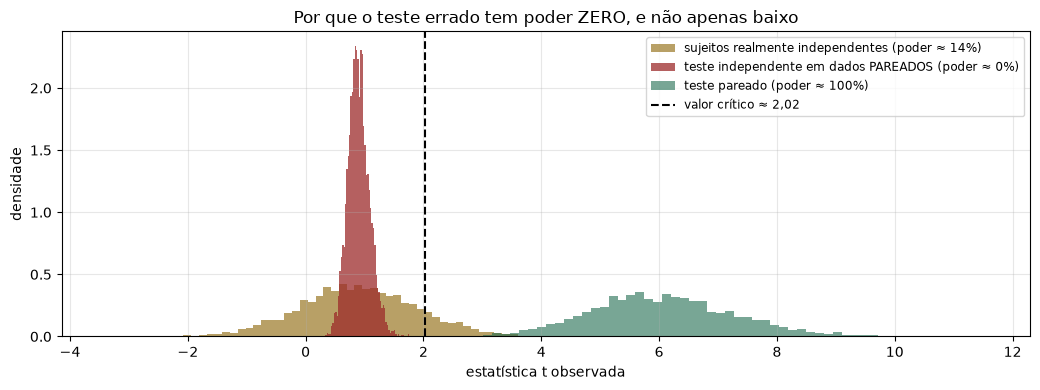

t do teste independente em dados pareados: média=0.902, dp=0.185
t com sujeitos de fato independentes     : média=0.894, dp=1.008

Mesma média, dispersões MUITO diferentes. A distribuição vermelha é
estreita e fica inteiramente à esquerda do valor crítico — por isso o
poder colapsa a zero em vez de simplesmente ficar baixo.


In [8]:
basal_sim = rng.normal(100, 20, (4_000, 40))
a_sim = basal_sim + rng.normal(0, 3, (4_000, 40))
b_sim = basal_sim + 4.0 + rng.normal(0, 3, (4_000, 40))
t_ind = stats.ttest_ind(b_sim, a_sim, axis=1, equal_var=False).statistic
t_par = stats.ttest_rel(b_sim, a_sim, axis=1).statistic

# Para comparar: os MESMOS parâmetros, mas com sujeitos de fato independentes
sd_total = np.sqrt(20**2 + 3**2)
a_ind = rng.normal(100, sd_total, (4_000, 40))
b_ind = rng.normal(104, sd_total, (4_000, 40))
t_verdadeiramente_ind = stats.ttest_ind(b_ind, a_ind, axis=1,
                                        equal_var=False).statistic

fig, ax = plt.subplots(figsize=(10.5, 4))
ax.hist(t_verdadeiramente_ind, bins=60, alpha=0.6, density=True, color=AMBAR,
        label="sujeitos realmente independentes (poder ≈ 14%)")
ax.hist(t_ind, bins=60, alpha=0.75, density=True, color=VERMELHO,
        label="teste independente em dados PAREADOS (poder ≈ 0%)")
ax.hist(t_par, bins=60, alpha=0.6, density=True, color=VERDE,
        label="teste pareado (poder ≈ 100%)")
ax.axvline(stats.t.ppf(0.975, 39), ls="--", color="black", lw=1.5,
           label="valor crítico ≈ 2,02")
ax.set_xlabel("estatística t observada")
ax.set_ylabel("densidade")
ax.set_title("Por que o teste errado tem poder ZERO, e não apenas baixo")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

print(f"t do teste independente em dados pareados: "
      f"média={t_ind.mean():.3f}, dp={t_ind.std(ddof=1):.3f}")
print(f"t com sujeitos de fato independentes     : "
      f"média={t_verdadeiramente_ind.mean():.3f}, "
      f"dp={t_verdadeiramente_ind.std(ddof=1):.3f}")
print("\nMesma média, dispersões MUITO diferentes. A distribuição vermelha é")
print("estreita e fica inteiramente à esquerda do valor crítico — por isso o")
print("poder colapsa a zero em vez de simplesmente ficar baixo.")

> **No mercado:** esta é exatamente a ideia por trás do **CUPED**, a técnica de
> redução de variância mais usada em experimentação online. Ela usa o
> comportamento **pré-experimento** de cada usuário como covariável, obtendo
> boa parte do ganho do pareamento sem precisar de um desenho pareado.
> Retomamos isso no módulo de A/B testing.

## 6. Verificando os pressupostos — na ordem certa

PROTOCOLO DE VERIFICAÇÃO

1. Independência das observações
   -> NÃO é testável nos dados; vem do DESENHO do estudo.
      Pergunte: houve aleatorização? há medidas repetidas do
      mesmo usuário? há efeito de rede entre unidades?

2. Formato das distribuições
   grupo 1: n=45, assimetria=+1.82, curtose exc.=+2.93
   grupo 2: n=52, assimetria=+3.33, curtose exc.=+12.06

3. Variâncias comparáveis (Levene, robusto a não-normalidade)
   Levene: p = 0.3660 -> sem evidência de variâncias diferentes
   (mas usaremos Welch de qualquer forma — o pré-teste é dispensável)

4. Os testes
   t de Welch      : p = 0.0668
   Mann-Whitney U  : p = 0.0146
   Permutação      : p = 0.0802

5. Tamanho do efeito (o que o p-valor NÃO diz)
   d de Cohen = 0.364  (pequeno)
   Razão de medianas = 1.820


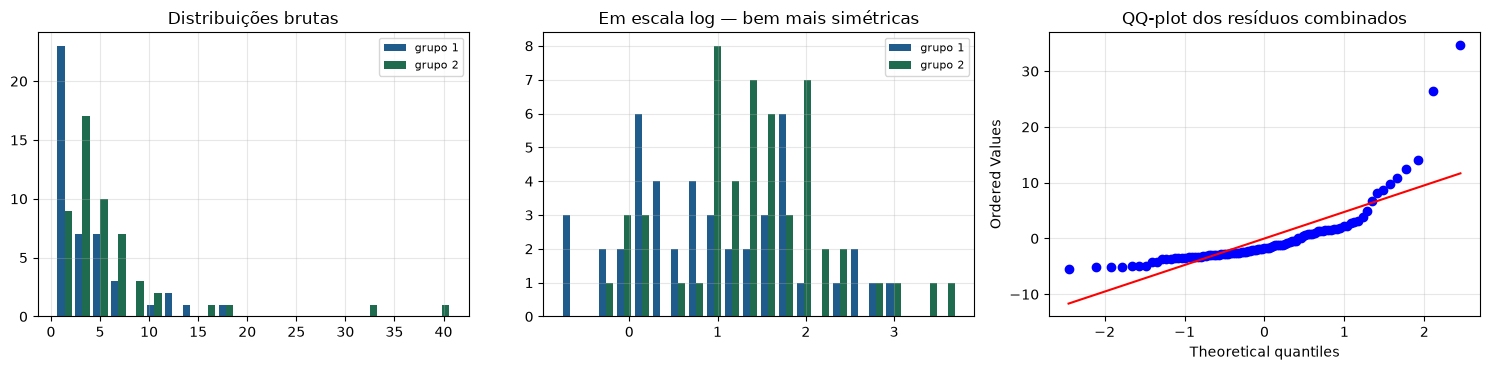

In [9]:
grupo1 = rng.lognormal(1.0, 0.9, 45)
grupo2 = rng.lognormal(1.3, 0.9, 52)

print("PROTOCOLO DE VERIFICAÇÃO\n")
print("1. Independência das observações")
print("   -> NÃO é testável nos dados; vem do DESENHO do estudo.")
print("      Pergunte: houve aleatorização? há medidas repetidas do")
print("      mesmo usuário? há efeito de rede entre unidades?\n")

print("2. Formato das distribuições")
for nome, g in [("grupo 1", grupo1), ("grupo 2", grupo2)]:
    print(f"   {nome}: n={len(g)}, assimetria={stats.skew(g):+.2f}, "
          f"curtose exc.={stats.kurtosis(g):+.2f}")

print("\n3. Variâncias comparáveis (Levene, robusto a não-normalidade)")
lev = stats.levene(grupo1, grupo2, center="median")
print(f"   Levene: p = {lev.pvalue:.4f} -> "
      f"{'sem evidência de variâncias diferentes' if lev.pvalue>0.05 else 'variâncias diferentes'}")
print("   (mas usaremos Welch de qualquer forma — o pré-teste é dispensável)\n")

print("4. Os testes")
print(f"   t de Welch      : p = {stats.ttest_ind(grupo1, grupo2, equal_var=False).pvalue:.4f}")
print(f"   Mann-Whitney U  : p = {stats.mannwhitneyu(grupo1, grupo2).pvalue:.4f}")
print(f"   Permutação      : ", end="")

combinado = np.concatenate([grupo1, grupo2])
obs = grupo2.mean() - grupo1.mean()
nulas = np.array([np.random.default_rng(i).permutation(combinado)[len(grupo1):].mean()
                  - np.random.default_rng(i).permutation(combinado)[:len(grupo1)].mean()
                  for i in range(5_000)])
print(f"p = {np.mean(np.abs(nulas) >= abs(obs)):.4f}")

print(f"\n5. Tamanho do efeito (o que o p-valor NÃO diz)")
dp_agrupado = np.sqrt(((len(grupo1)-1)*grupo1.var(ddof=1) +
                       (len(grupo2)-1)*grupo2.var(ddof=1)) /
                      (len(grupo1)+len(grupo2)-2))
d_cohen = (grupo2.mean() - grupo1.mean()) / dp_agrupado
print(f"   d de Cohen = {d_cohen:.3f}  "
      f"({'pequeno' if abs(d_cohen)<0.5 else 'médio' if abs(d_cohen)<0.8 else 'grande'})")
print(f"   Razão de medianas = {np.median(grupo2)/np.median(grupo1):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist([grupo1, grupo2], bins=22, label=["grupo 1", "grupo 2"],
             color=[AZUL, VERDE])
axes[0].set_title("Distribuições brutas")
axes[0].legend(fontsize=8)
axes[1].hist([np.log(grupo1), np.log(grupo2)], bins=22,
             label=["grupo 1", "grupo 2"], color=[AZUL, VERDE])
axes[1].set_title("Em escala log — bem mais simétricas")
axes[1].legend(fontsize=8)
stats.probplot(np.concatenate([grupo1 - grupo1.mean(), grupo2 - grupo2.mean()]),
               plot=axes[2])
axes[2].set_title("QQ-plot dos resíduos combinados")
plt.tight_layout()
plt.show()

## 7. Exercícios

1. Refaça a seção 2 com $n_1 = 5$ e $n_2 = 100$. A vantagem do Welch aumenta ou
   diminui? Existe algum cenário em que o Student é preferível?
2. Implemente o teste de **McNemar** para dados pareados binários (mesmo
   usuário viu as duas versões). Compare com um qui² ingênuo aplicado aos
   mesmos dados — quanto o qui² erra?
3. Aplique o teste de **Kolmogorov-Smirnov de duas amostras** a grupos com a
   mesma média mas variâncias diferentes. O KS detecta? E o teste t? O que isso
   ensina sobre o que cada teste "enxerga"?
4. Construa um exemplo em que o Mann-Whitney dá $p < 0{,}05$ mas as **medianas
   são idênticas**. (Dica: distribuições com formatos muito diferentes.) Isso
   confirma que ele não é um "teste de medianas".

## Próximo passo

`03-poder-e-tamanho-de-amostra.ipynb` — planejar o experimento antes de rodá-lo.